출발점 > 과적합을 피하는거 (상관없는 노이즈를 같이 학습시켜서)

ex) 다중공선성 억제 + 과적합 억제 역할을 하기 떄문에, vif 기준으로 전처리 안한채로 넣음

선형회귀에서만 vif 로 제거 (트리,릿지,라쏘,다항회귀 x)
vif 는 선형성 가정, 다른거는 거리,트리기반, 선형성 가정 x

상한선을 두거나 ㅌ특정값을 곱해서 계수가 너무 커지ㅣㅈ 않도록



릿지는 선형회귀의 문제를 개선 x 완화 정도...
중요하지 않은건 버리는걸 알고리즘이 알아서 함


EDA -> 지우거나 대체하는
OR 행단위 삭제 (결측치 확인)

데이터품질확인 과정에서는 LOG 변환 단계 X 

상관분석, ANOVA 는 원데이터로 하는거야

상관분석은 다중공선성확인용이라 종속변수는 안넣어도 무방

ANOVA 에서 유의미한 차이가 없으면 모형에 투입 X
(열단위의 삭제)


ANOVA 했을 떄 유의미하지 않아도 상관성이 높으면 너무 지우진마요 (교효작용 있을 수도 있음)


그 다음이 로그 변환 (모형한테 데이터주기 직전에)
그 데이터를 분리


*분리하고 70:30 그 데이터에 대해서 각각 부분에 스케일링 해야해

7 FIT TRANSFORM , 3 은 TRANSFORM


트레인 데이터에 대해서면 다중공선성 확인
만약 여기서 삭제되는 열이 생기면,,, 테스트 데이터에서도 제거해줘야함


규저,거리 기반 모델은 바로 스케일링
트리는 스케일링도 안해도 무방

파이프라인 클래스로 코드 흐름을 만들어줄 수있어
모듈


트레인데이터에 적용한 처리들을 훈련 데이터에도 자동으로 적요하는 모듈







================================
로그변환까지 딘 데이터셋


로그변환> 스케일링 > 하이퍼 파라미터>모형적합
각 모형마다 어떤 파라미턱 ㅏ있는지 고민하기


파이프라인 튜픙릉ㄹ 원소로 갖는 리스트 데이터를 준다
작업 순서대로.....
스케일링 > 학습 모형

앞에 이름 지어준거 SCALER, MODEL

작업 __ 언더바 두개 + 하이퍼파라미터 이름

릿지클래스에 ALPHA 파라미터에 하나씩테스트 하는거 -> 로그 스케일로 맞춰서...


교차검증 5회@ 설명력 위주로!

PIPELINE 이 나중에 X_TEST 데이터르 할떄 알아서 스케일링까지 해줌



ESTIMATOR 는 베스트 추정기를 받게 되는 것
GRID SC > 25개 테스트하고, 


LEARNING CURVE 에서는 원본데이터를 걸어줘야해 
ESTIMATOR 가 30 70 데이터 나눠서 알아서 스케일링까지 다 함



전달받은ㄷ ㅔ이터 10% -100%까지 8단계로 쪼개서 에러율을 점검해라


데이터들에 대해서 평균낸다 교차검증의 평균~
마지막 지점 뽑아거 최종훈련데이터


과적합은 다 도메인 기준

설명력이 세개중에 가장 작은것보다는 더 잘 나와라~ (주관적)


수치값이 아니라 그래프 모양으로 판정에서 뒤에 가서 만ㄷ날 기미가 있으면 채택하는게 나음




# [LAB 07] 지도학습 > 예측 > 선형 > 규제적용 > Ridge

## #01. 릿지 회귀 개요
- 선형회기에 벌점을 추가해서 과적합을 줄이는 방법
- 선형회귀가 너무 과하게 학습하지 않도록 계수에 브레이크를 거는 방법
- 독립변수가 너무 많이 있는 모델에 패널티를 부과해서 선형회귀의 과적합 방지 (모델 성능에 크게 기여하지 못하는 변수의 영향력을 제거하거나 축소시킴)
- 일반적인 선형회귀는 MSE (잔차제곱합이 최소)로 게싼하지만, 패널티 회귀분석에는 제곱합에 패널티 항 람다가 붙어, 제곱합과 패널티항의 합이 최소가 되는 회귀계수를 추정함
- 

### [1] 일반 선형회귀의 문제점
- 변수 수가 많음
- 변수들끼리 강하게 연관되면 다중공선성 발생
- 계수가 과도하게 커짐
- 학습 데이터에는 잘 맞지만 새로운 데이터에는 성능이 별로임
- 독립변수 갯수가 표본 크기에 비해 지나치게 많으면 제대로 성능 발휘가 어렵
- 불필요한 회귀 계수가 있으면 모델의 예측 성능을 저하시킴
- 많은 독립변수가 존재하면 회귀 계수의 영향력이 과도하게 높게 측정될 수 있음
  > 릿지 회귀는 선형 회귀의 단점을 완화


### [2] 핵심 아이디어
- 계수가 너무 커지면 벌점 부과
- 모든 계수를 조금씩 줄임
- 중요 변수는 남기되, 극단적인 값 방지
- 릿지 회귀분석은 회귀 계수를 0에 가깝도록 축소시키지만 0 으로 만드는 것은 아님
- 즉 원래 데이터 셋에 있는 모든 독립변수가 릿지 회귀에서도 그대로 적용되긴 함



### [3] 언제 쓰면 좋은가?
- 변수 수가 많을 때 (관측갯수 보다 독립변수가 너무 많을때)
- 변수 간 상관관계 높음
- 해석보다 예측 안정성 중요
- 모델의 설명력에 기여하지 못하는 독립변수의 회귀계수 크기를 0에 근접하도록 축소시킴
ㅇ

### [4] 주의사항
- 다항회귀 , 릿지 ,라쏘, SDG 에서는 VIF 를 제거하지 않음
- 다항회귀의 경우 의도적으로 공선성을 생성하는 방식이기 떄문에, 다중공선성을 제거할 경우 2차항을 생성한 의미가 사라짐
- 릿지 ,라쏘, SDG는 다중공선성 해결을 위해 존재하는 방법이므로, 전처리 과정에서 VIF 필터링을 수행하게 되면 규제의 역할을 침범해서 분석 결과에 왜곡이 발생함. 즉 VIF 필터링 거치지 않고 원데이터로 돌려야함


### 추가 보충
#### 1. 회귀식 (선형회귀 / 릿지 공통)

선형회귀와 릿지 회귀에서 **예측에 사용되는 회귀식 자체는 동일**하다.


#### 2. 릿지 회귀(Ridge Regression)의 회귀식 특징

릿지 회귀는 회귀식이 바뀌는 것이 아니라,  
**손실함수에 규제항(penalty)을 추가하여 계수를 추정**한다.

#### 3. 람다(λ)와 베타(β) 값의 관계

##### (1) 기본 관계
- \(\lambda\)가 커질수록 → **패널티의 영향 증가**
- 패널티가 커질수록 → **회귀계수 \(|\beta|\)는 작아짐**
- 모든 \(\beta\)는 **0 방향으로 수축(shrinkage)**

---

#### (2) λ 값에 따른 모델 성격 변화

| λ 값 | 모델 특성 | β의 크기 |
|----|----|----|
| λ = 0 | 일반 선형회귀(OLS) | 큼 |
| λ 작음 | 약한 규제 | 조금 감소 |
| λ 큼 | 강한 규제 | 매우 작아짐 |
| λ → ∞ | 과소적합 | β ≈ 0 |

---

### (3) 중요한 해석 포인트
- λ가 커진다고 해서 **손실이 무조건 커지지는 않음**
- λ 증가 → 모델이 β를 줄여 **패널티 항 자체를 낮추도록 조정**
- 결과적으로:
  - 예측 오차 ↑
  - 분산 ↓
  - 편향 ↑  
  → **Bias–Variance Trade-off**

---

## 4. 핵심 요약

- 릿지 회귀의 회귀식은 선형회귀와 동일
- 차이는 **손실함수에 L2 패널티가 추가된다는 점**
- λ는 예측 정확도와 모델 단순성 사이의 균형을 조절
- λ가 커질수록 β는 자동으로 작아지며, 모델은 더 안정적이 된다


## #02.준비작업
### [1] 패키지 참조

In [2]:
from hossam import *
from pandas import DataFrame, read_excel
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np
import statsmodels as sm


#데이터 표준화 모듈
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,GridSearchCV,learning_curve

#릿지 회귀
from sklearn.linear_model import Ridge

#성능 평가 지표 모듈
from sklearn.metrics import(
  r2_score,
  mean_absolute_error,
  mean_squared_error,
  mean_absolute_percentage_error
)



### [2] 데이터 가져오기


In [3]:
origin=load_data('fish_processed')
origin.head()

농어의 길이,높이,두께,무게를 조사한 데이터의 전처리 버전


,길이,높이,두께,무게
0,8.4,2.11,1.41,1.931521
1,13.7,3.53,2.00,3.496508
2,15.0,3.82,2.43,3.713572
3,16.2,4.59,2.63,3.960813
4,17.4,4.59,2.94,4.262680


### [3] 훈련,검증 데이터 분리

In [4]:
df = origin

yname = '무게'
x=df.drop(columns=[yname])
y=df[yname]


x_train,x_test,y_train,y_test = train_test_split(
  x,y,test_size=0.25,random_state=52
)

x_train.shape,x_test.shape,y_train.shape,y_test.shape

((42, 3), (14, 3), (42,), (14,))

## #03 릿지 회귀 모형 적합
### [1] 주요 하이퍼 파라미터
릿지 회귀 튜닝은 alpha 하나로 규제 강도를 조절하는 문제

|하이퍼 파라미터 | 의미 | 기본값 | 역할 | 값 설정 가이드|
|-|-|-|-|-|
|alpha|규제의 강조 | 1.0 |계수 크기를 얼마나 강아게 조절할지 결정해줌 | 작게하면 선형회귀에 가까워지고, 크게설정하면 과적합 억제 효과가 강화된다|
|random_state|난수 시드|None|일부 solver에서 재현성|실험 재현 시 설정|


### 핵심 정리
- alpha 가 가장 중요한 파라미터
- 나머지는 대부분 기본값 유지해도 무방함
- 실무에서는 alpha 만 GridSearchCV로 튜닝하는 경우가 대부분

### [2] 모델 적합
릿지 모델은 데이터의 스케일에 민감하기 떄문에 반드시 스케일링을 적용해야함

In [6]:
%%time

#Ridge 모델 정의 (n_jobs 없음)

pipe = Pipeline([('scaler', StandardScaler()) , ('model',Ridge(random_state=52))])


#탐색할 하이퍼파라미터 그리드 설정
param_grid = {'model__alpha':[0.01,0.1,1,10,100]}

#그리드 서치 객체 생성
gs = GridSearchCV(estimator=pipe,param_grid=param_grid,cv=5,scoring='r2',n_jobs=-1)


gs.fit(x_train,y_train)

estimator=gs.best_estimator_

estimator

CPU times: total: 93.8 ms
Wall time: 2.67 s


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


## #04.성능 평가
### [1] 성능평가 지표

In [8]:
y_pred = estimator.predict(x_test)


result_df = DataFrame(
    {
        "결정계수(R2)": r2_score(y_test, y_pred),
        "평균절대오차(MAE)": mean_absolute_error(y_test, y_pred),
        "평균제곱오차(MSE)": mean_squared_error(y_test, y_pred),
        "평균오차(RMSE)": np.sqrt(mean_squared_error(y_test, y_pred)),
        "평균 절대 백분오차(MAPE)": mean_absolute_percentage_error(y_test, y_pred),
        "평균 비율 오차(MPE)": np.mean((y_test - y_pred) / y_test * 100),
    },
    index=["성능지표"],
)

result_df


,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차(MAPE),평균 비율 오차(MPE)
성능지표,0.984545,0.107336,0.017939,0.133938,0.019481,0.260348


### [2] 과적합 여부 확인

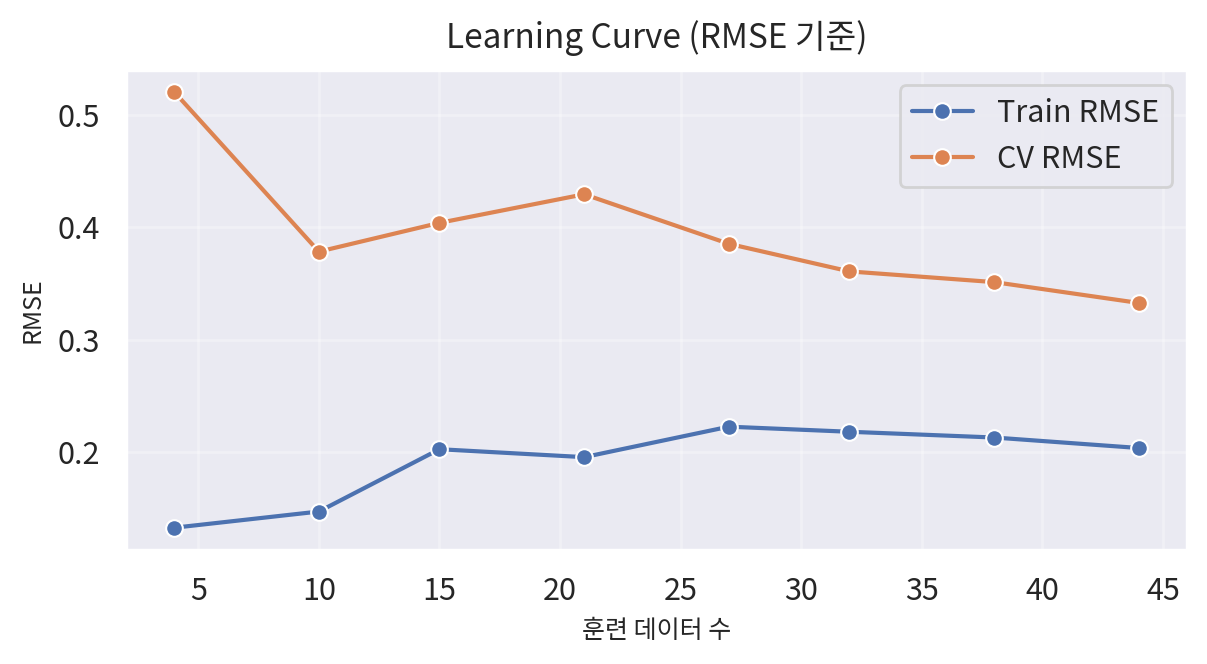

,지표,값
0,Train RMSE,0.203618
1,CV RMSE 평균,0.332544
2,CV RMSE 표준편차,0.214258
3,Train/CV 비율,0.612303
4,CV 변동성 비율,0.6443
5,판정 결과,⚠️과대적합 (variance 큼)


In [9]:
# ==========================
# # 과적합 여부 확인
# ==========================

# 반드시 원본 데이터 적용
train_sizes, train_scores, cv_scores = learning_curve(
    estimator=estimator,
    X=x,
    y=y,
    cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 8),
    shuffle=True,
    random_state=52,
    n_jobs=-1,
)

# neg RMSE -> RMSE
train_rmse = -train_scores
cv_rmse = -cv_scores

# 평균 / 표준편차
train_mean = train_rmse.mean(axis=1)
cv_mean = cv_rmse.mean(axis=1)
cv_std = cv_rmse.std(axis=1)

# 마지막 지점 기준 경향 판정
final_train = train_mean[-1]
final_cv = cv_mean[-1]
final_std = cv_std[-1]
gap_ratio = final_train / final_cv
var_ratio = final_std / final_cv

# --------------------------
# # 과적합 기준선 (some_threshold)
# --------------------------

# 기준모형 RMSE (평균예측)
y_mean = y.mean()
rmse_naive = np.sqrt(np.mean((y - y_mean) ** 2))

# 분산 기반
std_y = y.std()

# 최소 설명력(R^2) 기반
min_r2 = 0.10
rmse_r2 = np.sqrt((1 - min_r2) * np.var(y))

# 최종 threshold (가장 관대한 기준)
# -> 원래 some_threshold는 도메인 지식 수준에서 이 모델은 최소 어느 정도 성능은 내야 한다는 기준을 설정하는 것
some_threshold = min(rmse_naive, std_y, rmse_r2)

# --------------------------
# # 판정 로직
# --------------------------
if gap_ratio >= 0.95 and final_cv > some_threshold:
    status = "⚠️과소적합 (bias 큼)"
elif gap_ratio <= 0.8:
    status = "⚠️과대적합 (variance 큼)"
elif gap_ratio <= 0.95 and var_ratio <= 0.10:
    status = "✅일반화 양호"
elif var_ratio > 0.15:
    status = "⚠️데이터 부족 / 분산 큼"
else:
    status = "⚠️판단 유보"

# ==========================
# # 시각화 (Learning Curve)
# ==========================
figsize = (1280 / my_dpi, 720 / my_dpi)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

sb.lineplot(
    x=train_sizes,
    y=train_mean,
    marker="o",
    label="Train RMSE",
    ax=ax,
)
sb.lineplot(
    x=train_sizes,
    y=cv_mean,
    marker="o",
    label="CV RMSE",
    ax=ax,
)

ax.set_title("Learning Curve (RMSE 기준)", fontsize=12, pad=8)
ax.set_xlabel("훈련 데이터 수", fontsize=9)
ax.set_ylabel("RMSE", fontsize=9)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()
plt.close()

# ==========================
# # 정량 결과 표
# ==========================
result_df = DataFrame(
    {
        "지표": [
            "Train RMSE",
            "CV RMSE 평균",
            "CV RMSE 표준편차",
            "Train/CV 비율",
            "CV 변동성 비율",
            "판정 결과",
        ],
        "값": [
            final_train,
            final_cv,
            final_std,
            gap_ratio,
            var_ratio,
            status,
        ],
    }
)

result_df
